# Operaciones de aprendizaje automático
## Maestría en Inteligencia Artificial Aplicada

### TC5061 | Actividad: Dataset - Notebook | Individual

#### **Nombre:** Daniel Sanchez Hernandez
#### **Matrícula:** A01840324

## Objetivo
Recorrer de forma reproducible el flujo básico de un proyecto de Machine Learning: explorar y limpiar un conjunto de datos, entrenar y evaluar un modelo *baseline* y registrar el experimento en MLflow Tracking. 

## Dataset
**AI4I 2020 Predictive Maintenance Dataset** (Matzka, S., 2020). Conjunto de datos sintético que simula datos de una fresadora industrial, pensado para tareas de mantenimiento predictivo.

**¿Por qué este dataset?** Lo elegí porque se relaciona directamente con mi área profesional: trabajo en operaciones de TI en un entorno de manufactura (dispositivos electronicos medicos), donde los paros no planeados de equipo tienen un costo alto y el mantenimiento predictivo es un caso de uso real. Además, plantea retos útiles para practicar el flujo completo: un *target* fuertemente desbalanceado, etiquetas con inconsistencias que se pueden documentar y, como lo descubri sobre el camino, una relación no lineal entre las condiciones de operación y las fallas.

- Fuente original: [Kaggle - stephanmatzka](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)
- Licencia: Creative Commons Attribution 4.0 (CC BY 4.0).
- Problema a resolver: **clasificación binaria** - predecir si la máquina falla (`Machine failure`) a partir de las condiciones de operación.

## Nota de reproducibilidad
Este notebook debe ejecutarse desde la raíz del repositorio, donde existe la carpeta `data/raw/`. La configuración global (rutas, random seed y opciones de visualización) se define una sola vez, al inicio. La sección de MLflow requiere que el servidor de tracking esté activo (ver sección 6.1).

In [1]:
# Importación de librerías y registro de versiones (evidencia de reproducibilidad)
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", sns.__version__)
print("mlflow      :", mlflow.__version__)

Python      : 3.11.16
pandas      : 3.0.5
numpy       : 2.4.6
scikit-learn: 1.4.2
matplotlib  : 3.11.2
seaborn     : 0.13.2
mlflow      : 3.16.0


## Configuración global

Todas las decisiones que aplican al notebook completo se concentran en esta celda, para no repetirlas en cada paso y para que cualquier persona sepa dónde cambiarlas:
- **Ruta de datos:** ubicación del archivo original, que se trata como solo lectura.
- **Random seed (`SEED`):** se usará en el train/test split y en el modelo, para que los resultados sean reproducibles en cualquier ejecución.
- **Opciones de visualización:** pandas muestra todas las columnas y el texto completo de las celdas; las gráficas usan un estilo uniforme.
- **Colores de las gráficas:** el *target* usa azul (sin falla) y naranja (con falla). Se eligió una paleta apta para daltonismo porque soy daltónico y esto me facilita la lectura de las gráficas. Los colores se nombran con constantes (`BLUE`, `ORANGE`) en lugar de códigos hexadecimales sueltos, para que el código sea más legible y lo pueda reutilizar con más facilidad. El amarillo (`YELLOW`) se usa solo para elementos de referencia: la curva KDE en los histogramas y la media en los boxplots.

In [2]:
# Ruta del archivo original (solo lectura: nunca se modifica)
DATA_PATH = Path("data/raw/ai4i2020.csv")

# Ruta del dataset limpio (resultado de la limpieza de datos)
PROCESSED_PATH = Path("data/processed/ai4i2020_clean.csv")

# Random seed única para reproducibilidad
SEED = 42

# Opciones de visualización de pandas
pd.set_option("display.max_columns", None)   # mostrar todas las columnas
pd.set_option("display.width", 200)          # ancho suficiente para tablas amplias
pd.set_option("display.max_colwidth", None)  # no recortar textos largos

# Colores para daltonismo (hago esto porque soy daltónico)
BLUE = "#2a78d6"
ORANGE = "#eb6834"
YELLOW = "#eda100"

# Colores fijos para el target en todas las gráficas: 0 = sin falla, 1 = falla
TARGET_COLORS = {0: BLUE, 1: ORANGE}

# MLflow: servidor de tracking (debe estar activo) y nombre del experimento
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
MLFLOW_EXPERIMENT = "AI4I_Predictive_Maintenance"

## Paso 1: Carga y descripción del dataset

En este paso se importan los datos y se describe su estructura: número de registros, variables, tipos de dato y significado de cada columna.

**Schema validation:** después de cargar el archivo se verifica que contenga exactamente las columnas esperadas (práctica básica de validación de datos). Si la fuente cambia (una columna renombrada, faltante o adicional), el notebook se detiene con un mensaje claro.

In [3]:
# Leer el dataset
df = pd.read_csv(DATA_PATH)

# Columnas documentadas por el autor del dataset
EXPECTED_COLUMNS = ["UDI", "Product ID", "Type", "Air temperature [K]", "Process temperature [K]",
                    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
                    "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF",
]

# Comparación entre columnas esperadas y columnas reales
missing_columns = set(EXPECTED_COLUMNS) - set(df.columns)
extra_columns = set(df.columns) - set(EXPECTED_COLUMNS)

assert not missing_columns, f"Faltan columnas: {missing_columns}"
assert not extra_columns, f"Columnas no esperadas: {extra_columns}"
print("Schema validation OK: las", len(EXPECTED_COLUMNS), "columnas esperadas están presentes.")

Schema validation OK: las 14 columnas esperadas están presentes.


In [4]:
# Dimensiones del dataset: (registros, variables)
n_rows, n_cols = df.shape
print(f"Registros: {n_rows}")
print(f"Variables: {n_cols}")

Registros: 10000
Variables: 14


In [5]:
# Primeras y últimas filas para ver el aspecto real de los datos
display(df.head())
display(df.tail())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [6]:
# Estructura: tipo de dato y valores no nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [7]:
# Cardinalidad: valores distintos por columna (ayuda a distinguir identificadores, categóricas y numéricas)
df.nunique().to_frame(name="n_unique")

,n_unique
UDI,10000
Product ID,10000
Type,3
Air temperature [K],93
Process temperature [K],82
Rotational speed [rpm],941
Torque [Nm],577
Tool wear [min],246
Machine failure,2
TWF,2


### Diccionario de datos
La siguiente tabla documenta el rol, la descripción y la unidad de cada variable, en base a las descripciones y la documentación original del dataset (Matzka, 2020; [Kaggle](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)). Se añade una columna con el tipo de dato que pandas asignó realmente, para contrastarlo con la documentación.

Observaciones:
- La documentación llama `UID` al identificador, pero en el archivo CSV la columna se llama `UDI`; se usa el nombre real del archivo.
- UCI clasifica a `TWF`, `HDF`, `PWF`, `OSF` y `RNF` como *target*, no como *features*: son los cinco modos de falla y `Machine failure` vale 1 cuando ocurre al menos uno. Este punto se retoma al construir el modelo *baseline* más adelante.

In [8]:
# Diccionario de datos: descripciones tomadas de la documentación original
data_dictionary = pd.DataFrame(
    [
        ("UDI", "ID", "Unique identifier ranging from 1 to 10000", "-"),
        ("Product ID", "ID", "Consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number", "-"),
        ("Type", "Feature", "Just the product type L, M or H from column 2", "-"),
        ("Air temperature [K]", "Feature", "Generated using a random walk process later normalized to a standard deviation of 2 K around 300 K", "K"),
        ("Process temperature [K]", "Feature", "Generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K", "K"),
        ("Rotational speed [rpm]", "Feature", "Calculated from a power of 2860 W, overlaid with a normally distributed noise", "rpm"),
        ("Torque [Nm]", "Feature", "Torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values", "Nm"),
        ("Tool wear [min]", "Feature", "The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process", "min"),
        ("Machine failure", "Target", "Label that indicates whether the machine has failed in this particular datapoint for any of the failure modes", "-"),
        ("TWF", "Target", "Tool wear failure", "-"),
        ("HDF", "Target", "Heat dissipation failure", "-"),
        ("PWF", "Target", "Power failure", "-"),
        ("OSF", "Target", "Overstrain failure", "-"),
        ("RNF", "Target", "Random failures", "-"),
    ],
    columns=["Variable", "Role", "Description", "Units"],
)

# Tipo de dato real asignado por pandas, para contrastarlo con la documentación
data_dictionary["pandas dtype"] = data_dictionary["Variable"].map(df.dtypes.astype(str))
data_dictionary

,Variable,Role,Description,Units,pandas dtype
0,UDI,ID,Unique identifier ranging from 1 to 10000,-,int64
1,Product ID,ID,"Consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number",-,str
2,Type,Feature,"Just the product type L, M or H from column 2",-,str
3,Air temperature [K],Feature,Generated using a random walk process later normalized to a standard deviation of 2 K around 300 K,K,float64
4,Process temperature [K],Feature,"Generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K",K,float64
5,Rotational speed [rpm],Feature,"Calculated from a power of 2860 W, overlaid with a normally distributed noise",rpm,int64
6,Torque [Nm],Feature,Torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values,Nm,float64
7,Tool wear [min],Feature,The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process,min,int64
8,Machine failure,Target,Label that indicates whether the machine has failed in this particular datapoint for any of the failure modes,-,int64
9,TWF,Target,Tool wear failure,-,int64


## Paso 2: Análisis exploratorio de datos (EDA)

El objetivo del EDA es entender los datos antes de modelar: cómo se distribuye cada variable, qué tan balanceado está el *target* y qué *features* parecen relacionarse con las fallas. Los hallazgos de este paso nos ayudarán a la toma de decisiones de la limpieza de datos y del modelo *baseline*.

Se analizan:
- **Estadística descriptiva** de las *features* numéricas y de la variable categórica `Type`.
- **Balance de clases** del *target* `Machine failure`.
- **Modos de falla** y su consistencia con el *target*.
- **Distribuciones** de las *features* numéricas.
- **Correlaciones** entre las *features* y el *target*, y entre las propias *features*.

Nota. Los identificadores `UDI` y `Product ID` se excluyen del análisis porque no contienen información predictiva.

In [9]:
# Grupos de columnas que se reutilizan en el resto del notebook
TARGET = "Machine failure"
FAILURE_MODES = ["TWF", "HDF", "PWF", "OSF", "RNF"]
NUMERIC_FEATURES = ["Air temperature [K]", "Process temperature [K]",
                    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
]
# Rol en el modelo: features categóricas que se usarán para entrenar
CATEGORICAL_FEATURES = ["Type"]

# Tipo de dato: columnas de texto, para resumirlas con describe() (incluye el identificador Product ID)
TEXT_COLUMNS = ["Product ID", "Type"]

### 2.1 Estadística descriptiva

Usamos `describe()` para resumir todas las estadísticas descriptivas de cada *feature* numérica: conteo, media, desviación estándar, mínimo, cuartiles y máximo. Encima de eso agregamos:
- **Asimetría (*skewness*):** un valor cercano a 0 indica una distribución simétrica; valores mayores a 1 indican una cola larga hacia la derecha.
- **Curtosis (*kurtosis*):** mide qué tan pesadas son las colas. pandas calcula la curtosis en exceso, donde una distribución normal vale 0: valores positivos indican colas pesadas (más valores extremos de lo normal) y valores negativos indican colas ligeras o una distribución más plana.

In [10]:
# Resumen estadístico de las features numéricas
summary = df[NUMERIC_FEATURES].describe().T
summary["skewness"] = df[NUMERIC_FEATURES].skew()
summary["kurtosis"] = df[NUMERIC_FEATURES].kurt()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Air temperature [K],10000.0,300.00,2.00,295.3,298.3,300.1,301.5,304.5,0.11,-0.84
Process temperature [K],10000.0,310.01,1.48,305.7,308.8,310.1,311.1,313.8,0.02,-0.50
Rotational speed [rpm],10000.0,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0,1.99,7.39
Torque [Nm],10000.0,39.99,9.97,3.8,33.2,40.1,46.8,76.6,-0.01,-0.01
Tool wear [min],10000.0,107.95,63.65,0.0,53.0,108.0,162.0,253.0,0.03,-1.17


**Observaciones de la estadística descriptiva:**
- **Sin valores faltantes:** las cinco *features* tienen 10,000 registros (`count`).
- **`Air temperature [K]` y `Process temperature [K]`:** medias de 300.00 K y 310.01 K, con desviaciones de 2.00 K y 1.48 K, tal como describe la documentación (la temperatura del proceso es la del aire más ~10 K). Ambas son simétricas (*skewness* 0.11 y 0.02) y algo más planas que una normal (*kurtosis* -0.84 y -0.50).
- **`Rotational speed [rpm]`:** la media (1538.78) es mayor que la mediana (1503), señal de una cola hacia la derecha. Lo confirman la *skewness* (1.99) y la *kurtosis* (7.39), la más alta del dataset: hay valores extremos, con un máximo de 2886 rpm.
- **`Torque [Nm]`:** media 39.99 y desviación 9.97, coherente con la documentación (40 +/- 10 Nm). Con *skewness* y *kurtosis* prácticamente en 0 (-0.01 y -0.01), es la *feature* más cercana a una distribución normal. El mínimo (3.8 Nm) confirma que no hay valores negativos.
- **`Tool wear [min]`:** media (107.95) y mediana (108) casi iguales, sin asimetría (0.03). Su *kurtosis* negativa (-1.17) indica una distribución plana, cercana a uniforme. El máximo (253 min) supera el rango de 200 a 240 min en el que, según la documentación, la herramienta se reemplaza o falla; 11 registros están por encima de 240 min.

Para las columnas de texto, `describe()` muestra el número de valores distintos (`unique`), el valor más frecuente (`top`) y su frecuencia (`freq`).

In [11]:
# Resumen de las columnas de texto: valores únicos, valor más frecuente y su frecuencia
df[TEXT_COLUMNS].describe().T

,count,unique,top,freq
Product ID,10000,10000,M14860,1
Type,10000,3,L,6000


In [12]:
# Conteo y porcentaje por valor de cada variable categórica
# (Product ID se omite: sus 10,000 valores son únicos y la lista no aporta información)
for column in CATEGORICAL_FEATURES:
    counts = pd.concat([df[column].value_counts(),
                        df[column].value_counts(normalize=True).mul(100).round(2)],
                       axis=1, keys=["count", "percent"],
    )
    print(counts)
    # print("-" * 45)

      count  percent
Type                
L      6000    60.00
M      2997    29.97
H      1003    10.03


**Observación:** según la documentación, las variantes de calidad se reparten como L 50%, M 30% y H 20%. En los datos, M coincide (29.97%), pero L representa el 60% y H solo el 10.03%. La diferencia no afecta el análisis, pero se documenta porque los datos no reflejan exactamente la descripción de su fuente.

### 2.2 Balance de clases del *target*

En un problema de clasificación es indispensable revisar qué proporción de registros pertenece a cada clase. Si una clase es muy minoritaria, la métrica *accuracy* puede ser engañosa: un modelo que siempre predice "sin falla" acertaría casi siempre sin detectar ninguna falla.

                 count  percent
Machine failure                
0                 9661    96.61
1                  339     3.39


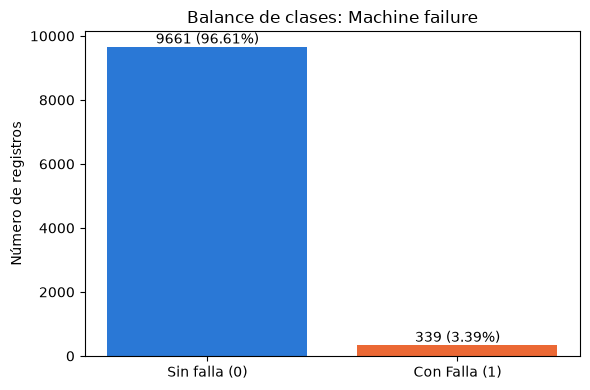

In [13]:
# Conteo y porcentaje de cada clase del target
target_counts = pd.DataFrame({"count": df[TARGET].value_counts(),
                              "percent": df[TARGET].value_counts(normalize=True).mul(100).round(2),
})
print(target_counts)

# Gráfica de barras del balance de clases
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Sin falla (0)", "Con Falla (1)"], target_counts["count"].sort_index(),
       color=[TARGET_COLORS[0], TARGET_COLORS[1]],
)
for i, value in enumerate(target_counts["count"].sort_index()):
    ax.text(i, value, f"{value} ({value / len(df):.2%})", ha="center", va="bottom")
ax.set_title("Balance de clases: Machine failure")
ax.set_ylabel("Número de registros")
plt.tight_layout()
plt.show()

### 2.3 Modos de falla y consistencia de etiquetas

Según la documentación, `Machine failure` vale 1 cuando ocurre al menos uno de los cinco modos de falla. Se verifica si esa regla se cumple en los datos, comparando el *target* contra la presencia de algún modo de falla.

In [14]:
# Número de registros con cada modo de falla
print("Registros por modo de falla:")
print(df[FAILURE_MODES].sum().to_string())

# Número de modos de falla activos en cada registro
n_modes = df[FAILURE_MODES].sum(axis=1)

# Tabla cruzada: target contra "tiene al menos un modo de falla"
print("\nTarget vs. presencia de algún modo de falla:\n")
print(pd.crosstab(df[TARGET], n_modes > 0,
                  rownames=[TARGET], colnames=["Algún modo de falla"],
))

print("\nFallas sin ningún modo registrado:", ((df[TARGET] == 1) & (n_modes == 0)).sum())
print("Modo de falla sin falla registrada:", ((df[TARGET] == 0) & (n_modes > 0)).sum())
print("Registros con más de un modo de falla:", (n_modes > 1).sum())

Registros por modo de falla:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19

Target vs. presencia de algún modo de falla:

Algún modo de falla  False  True 
Machine failure                  
0                     9643     18
1                        9    330

Fallas sin ningún modo registrado: 9
Modo de falla sin falla registrada: 18
Registros con más de un modo de falla: 24


**Observaciones sobre los modos de falla:**
- **18 registros con modo de falla pero sin falla:** todos corresponden a `RNF` (falla aleatoria). De los 19 registros con `RNF` = 1, solo 1 tiene `Machine failure` = 1. Según la documentación, `RNF` es una probabilidad de falla del 0.1% independiente de las condiciones de operación, por lo que estos registros contradicen la regla "falla = al menos un modo de falla".
- **9 fallas sin ningún modo registrado:** la máquina falló, pero el dataset no indica la causa. Representan el 2.65% de las 339 fallas.
- **24 registros con más de un modo de falla:** no son un error; la documentación permite que varios modos ocurran a la vez, y en todos ellos `Machine failure` = 1.
- **Impacto:** las 27 inconsistencias equivalen al 0.27% del dataset, pero afectan directamente a la clase minoritaria. La decisión de cómo tratarlas se toma en la limpieza de datos.

### 2.4 Distribución de las *features* numéricas

Los histogramas muestran la forma de cada distribución: simetría, sesgo, posibles outliers y rangos. La línea amarilla punteada es la curva KDE (*Kernel Density Estimation*): una versión suavizada del histograma que facilita ver la forma general de la distribución.

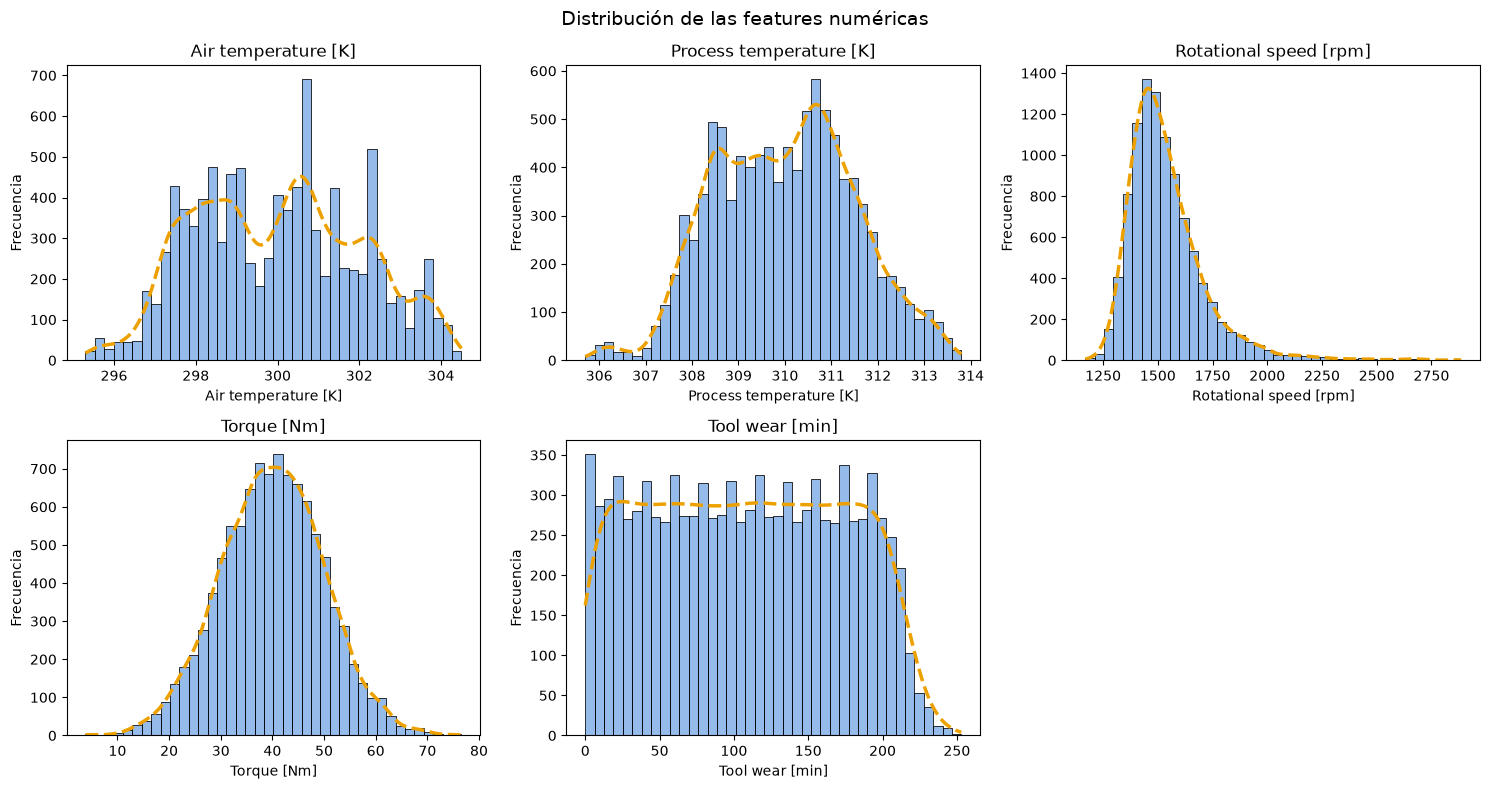

In [15]:
# Un histograma por feature numérica
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(data=df, x=feature, bins=40, color=TARGET_COLORS[0], ax=ax,
                 kde=True, line_kws={"linestyle": "--", "linewidth": 2.5},
    )
    ax.lines[-1].set_color(YELLOW)
    ax.set_title(feature)
    ax.set_ylabel("Frecuencia")
axes.flat[-1].set_visible(False)  # la cuadrícula tiene 6 espacios y solo hay 5 features
fig.suptitle("Distribución de las features numéricas", fontsize=14)
plt.tight_layout()
plt.show()

### 2.5 Relación de las *features* con el *target*

Los diagramas de caja (*boxplots*) comparan la distribución de cada *feature* entre registros sin falla y con falla. Si las cajas se separan, la *feature* aporta información para distinguir las clases. En cada caja, la línea vertical es la mediana y el cuadro amarillo es la media.

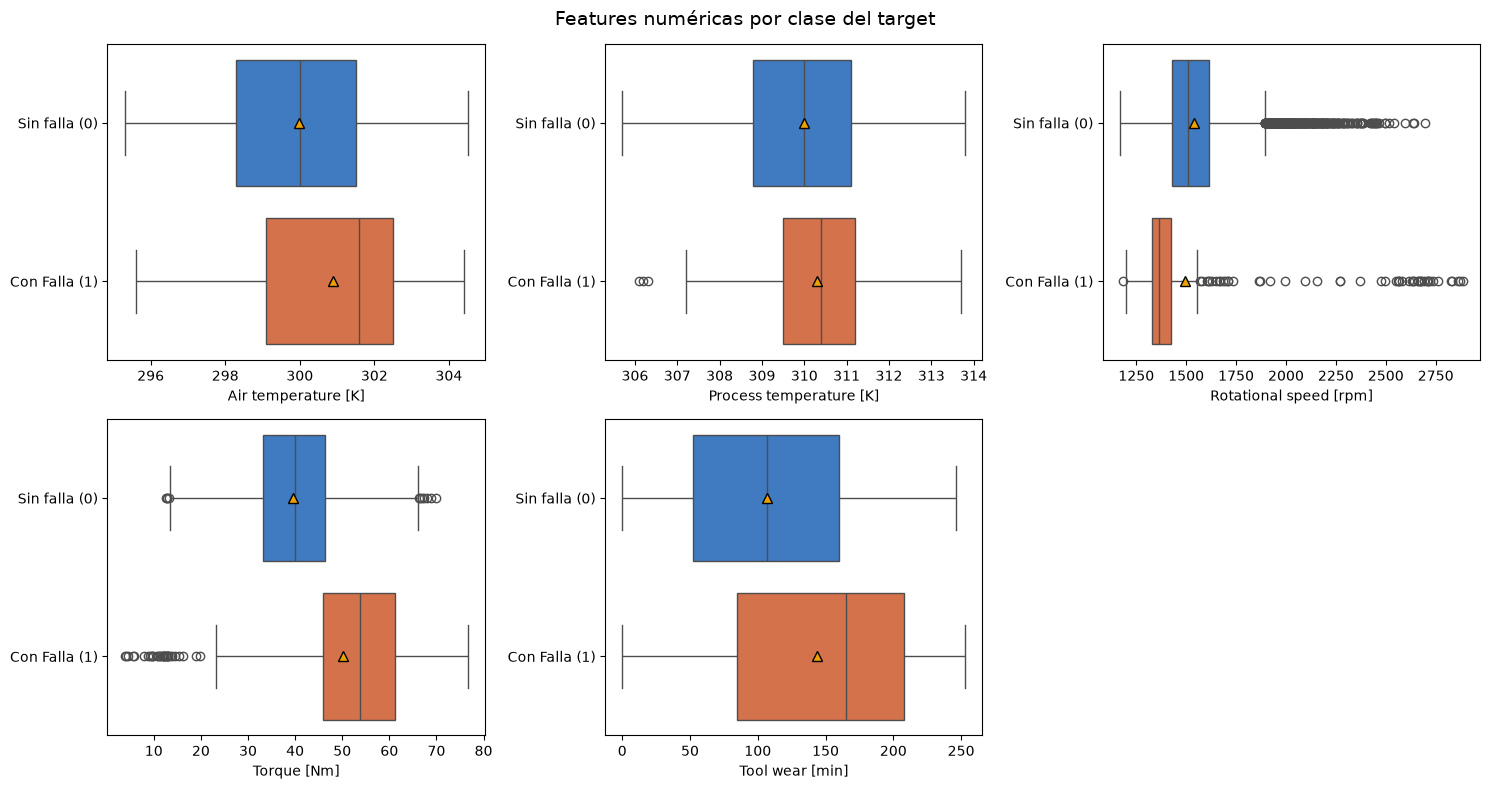

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,300.0,310.0,1507.0,39.9,107.0
1,301.6,310.4,1365.0,53.7,165.0


In [16]:
# Boxplot de cada feature numérica, separado por clase del target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.flat, NUMERIC_FEATURES):
    sns.boxplot(data=df, x=feature, y=TARGET, hue=TARGET, orient="h",
                palette=TARGET_COLORS, legend=False, ax=ax,
                showmeans=True,
                meanprops={"marker": "^", "markerfacecolor": YELLOW,
                           "markeredgecolor": "black", "markersize": 7},
    )
    # ax.set_title(feature)
    ax.set_yticks([0, 1], ["Sin falla (0)", "Con Falla (1)"])
    ax.set_ylabel("")
axes.flat[-1].set_visible(False)
fig.suptitle("Features numéricas por clase del target", fontsize=14)
plt.tight_layout()
plt.show()

# Mediana de cada feature por clase, como apoyo numérico a la gráfica
df.groupby(TARGET)[NUMERIC_FEATURES].median().round(1)

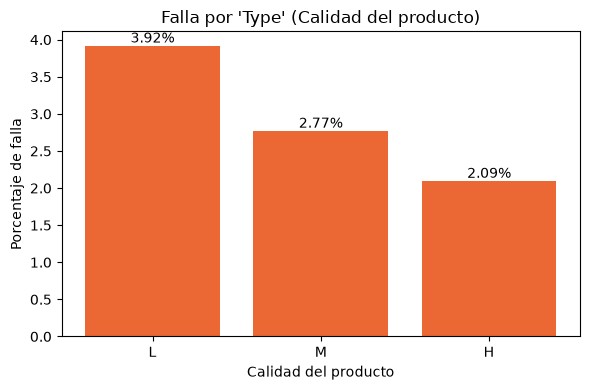

In [17]:
# Porcentaje de falla por tipo de producto
failure_rate_by_type = (df.groupby("Type")[TARGET].mean()
                        .mul(100)
                        .reindex(["L", "M", "H"])
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(failure_rate_by_type.index, failure_rate_by_type.values, color=TARGET_COLORS[1])
for i, value in enumerate(failure_rate_by_type.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")
ax.set_title("Falla por 'Type' (Calidad del producto)")
ax.set_xlabel("Calidad del producto")
ax.set_ylabel("Porcentaje de falla");
plt.tight_layout()
plt.show()

### 2.6 Correlación entre variables

Usamos una matriz de correlación de Pearson para medir las relaciones **lineales** entre pares de variables y para detectar *features* redundantes entre sí y relaciones lineales con el *target*. Una correlación baja no descarta relaciones no lineales.

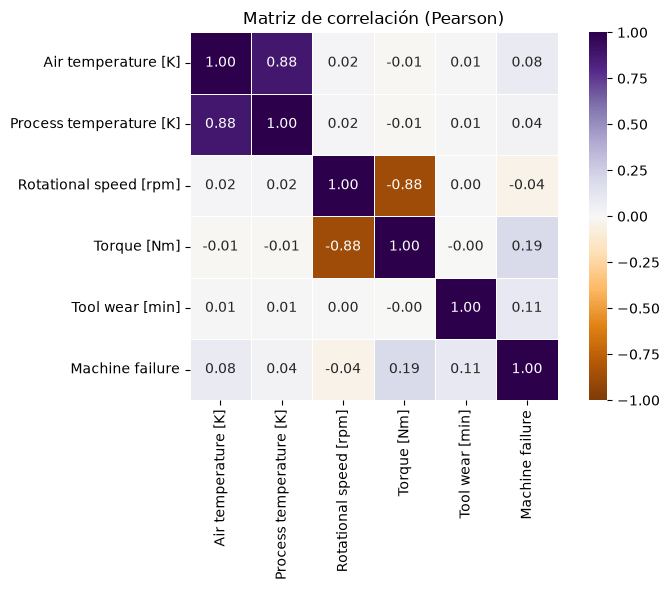

In [18]:
# Matriz de correlación de las features numéricas y el target
corr = df[NUMERIC_FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PuOr", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

### 2.7 Hallazgos del EDA

1. **Fuerte desbalance de clases:** solo el 3.39% de los registros (339 de 10,000) son fallas. *Accuracy* no es una métrica adecuada para este problema; en la evaluación del modelo se usarán métricas centradas en la clase minoritaria (*recall*, *precision*, F1). El train/test split debe ser estratificado para conservar esta proporción en entrenamiento y prueba.
2. **Etiquetas inconsistentes:** la regla documentada ("falla = al menos un modo de falla") no se cumple en 27 registros: 9 fallas sin ningún modo registrado y 18 registros con `RNF` = 1 pero sin falla. Además, 24 registros presentan más de un modo de falla a la vez, lo cual es válido. Las inconsistencias se tratan en la limpieza de datos.
3. **Distribuciones:** `Air temperature [K]`, `Process temperature [K]` y `Torque [Nm]` tienen distribuciones aproximadamente simétricas, y `Torque [Nm]` es prácticamente normal (*skewness* y *kurtosis* de -0.01). `Tool wear [min]` es casi uniforme entre 0 y ~200 min, lo que confirma su *kurtosis* negativa (-1.17). `Rotational speed [rpm]` tiene una cola larga hacia la derecha (*skewness* 1.99) y colas pesadas (*kurtosis* 7.39); sus valores altos parecen outliers, pero se revisan en la limpieza de datos antes de decidir, porque pueden ser físicamente válidos.
4. **Relación con el *target*:** las fallas se asocian con mayor `Torque [Nm]` (mediana 53.7 vs. 39.9 Nm), mayor `Tool wear [min]` (165 vs. 107 min), menor `Rotational speed [rpm]` (1365 vs. 1507 rpm) y `Air temperature [K]` ligeramente mayor. En `Torque [Nm]` y `Rotational speed [rpm]`, **las fallas aparecen en ambos extremos** (muy alta velocidad con torque muy bajo, y viceversa), un patrón coherente con la falla de potencia (`PWF`). Las medias de la clase con falla lo confirman: en `Rotational speed [rpm]` la media (1496.5) queda muy por encima de la mediana (1365), arrastrada por las fallas a muy alta velocidad, y en `Torque [Nm]` la media (50.2) queda por debajo de la mediana (53.7), arrastrada por las fallas con torque muy bajo. `Tool wear [min]` muestra el mismo efecto (media 143.8 vs. mediana 165) por las fallas que ocurren con poco desgaste.
5. **Type:** la tasa de falla disminuye con la calidad del producto: L 3.92%, M 2.77%, H 2.09%. `Type` aporta información y se conservará como *feature*. Su distribución (L 60%, M 30%, H 10%) difiere de la documentada (50/30/20).
6. **Correlación:** hay dos pares de *features* fuertemente correlacionados: `Air temperature [K]` con `Process temperature [K]` (0.88) y `Rotational speed [rpm]` con `Torque [Nm]` (-0.88), lo que es consistente con cómo se generó el dataset. Ninguna *feature* tiene una correlación lineal alta con el *target* (máximo 0.19, `Torque [Nm]`); dado el patrón de extremos del punto 4, la relación con las fallas es no lineal, lo que se considerará al elegir el modelo *baseline*.

## Paso 3: Limpieza de datos

En este paso se revisan los problemas de calidad más comunes (valores faltantes, duplicados, tipos de dato incorrectos y outliers) junto con los hallazgos del EDA. Se documenta la decisión tomada en cada caso. Para el análisis que no encuentra problemas, también se deja la evidencia demostrando que los datos están limpios.

Todas las transformaciones se aplican sobre una copia (`df_clean`). El DataFrame original `df` y el archivo en `data/raw/` no se modifican.

In [19]:
# Copia para dejar DataFrame original intacto
df_clean = df.copy()

### 3.1 Valores faltantes

In [20]:
# Número de valores faltantes por columna
missing_values = df_clean.isna().sum()
print(missing_values.to_string())
print("\nTotal de valores faltantes:", missing_values.sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0

Total de valores faltantes: 0


**Decisión:** no hay valores faltantes en ninguna columna, por lo que no se requiere imputación ni eliminación de registros.

### 3.2 Registros duplicados

Se revisan los duplicados de dos formas: con todas las columnas, y sin los identificadores `UDI` y `Product ID`. La segunda revisión es la importante, porque los IDs son únicos por diseño y ocultarían registros que repiten exactamente las mismas condiciones de operación.

In [21]:
# Duplicados considerando todas las columnas
print("Duplicados (todas las columnas):", df_clean.duplicated().sum())

# Duplicados sin los identificadores
print("Duplicados (sin UDI ni Product ID):", df_clean.drop(columns=["UDI", "Product ID"]).duplicated().sum())

Duplicados (todas las columnas): 0
Duplicados (sin UDI ni Product ID): 0


**Decisión:** no hay registros duplicados, por lo que no se elimina ninguno.

### 3.3 Tipos de datos y consistencia interna

Los tipos de datos se revisaron en la carga del dataset (todos coinciden con el significado de cada variable). Aquí se valida además que los valores sean coherentes entre sí y con la documentación.

In [22]:
# Diferencia entre la temperatura del proceso y la del aire (documentada como ~10 K)
temp_diff = df_clean["Process temperature [K]"] - df_clean["Air temperature [K]"]

# Reglas de consistencia: cada una debe cumplirse en todos los registros
consistency_checks = {"Clasificación de Product ID coincide con Type": (df_clean["Product ID"].str[0] == df_clean["Type"]).all(),
                      "Type solo contiene L, M o H": df_clean["Type"].isin(["L", "M", "H"]).all(),
                      "Process temperature es mayor que Air temperature": (temp_diff > 0).all(),
                      "Sin valores negativos en las features numéricas": (df_clean[NUMERIC_FEATURES] >= 0).all().all(),
                      "Target y modos de falla solo toman valores 0 o 1": df_clean[[TARGET] + FAILURE_MODES].isin([0, 1]).all().all(),
}
consistency_summary = pd.Series(consistency_checks, name="Cumple").to_frame()
print(f"Diferencia de temperatura (proceso - aire): mínimo {temp_diff.min():.1f} K, máximo {temp_diff.max():.1f} K\n")
consistency_summary

Diferencia de temperatura (proceso - aire): mínimo 7.6 K, máximo 12.1 K



,Cumple
Clasificación de Product ID coincide con Type,True
"Type solo contiene L, M o H",True
Process temperature es mayor que Air temperature,True
Sin valores negativos en las features numéricas,True
Target y modos de falla solo toman valores 0 o 1,True


**Decisión:** todas las reglas se cumplen y los tipos de dato son correctos, por lo que no se requieren conversiones ni correcciones.

### 3.4 Etiquetas inconsistentes

En el EDA se encontró que la regla documentada *`Machine failure` = 1 si y solo si ocurre al menos un modo de falla* no se cumple en 27 registros:
- **9 fallas sin ningún modo registrado:** la máquina falló, pero no se indica la causa.
- **18 registros con `RNF` = 1 pero sin falla:** el modo de falla aleatoria está marcado, pero el *target* dice que no hubo falla.

In [23]:
# Número de modos de falla activos en cada registro
n_active_modes = df_clean[FAILURE_MODES].sum(axis=1)

# Registros que contradicen la regla documentada, en cualquiera de los dos sentidos
inconsistent = (((df_clean[TARGET] == 1) & (n_active_modes == 0)) |
                ((df_clean[TARGET] == 0) & (n_active_modes > 0))
)
print("Registros inconsistentes:\n", inconsistent.sum())
print("  Fallas sin modo registrado:", ((df_clean[TARGET] == 1) & (n_active_modes == 0)).sum())
print("  Modo de falla sin falla:", ((df_clean[TARGET] == 0) & (n_active_modes > 0)).sum())

Registros inconsistentes:
 27
  Fallas sin modo registrado: 9
  Modo de falla sin falla: 18


**Decisión: eliminar los 27 registros inconsistentes.**

Justificación:
1. **El dataset se contradice.** La documentación establece que `Machine failure` vale `1` exactamente cuando ocurre al menos un modo de falla. En estos registros la regla se rompe en ambos sentidos, y no hay forma de saber cuál columna es la incorrecta: el *target* o el modo de falla. Entrenar con etiquetas que no son confiables introduce ruido justo en la clase que se quiere predecir.
2. **El riesgo es calculado y medible.** Se eliminan 27 registros (0.27% del dataset). La clase minoritaria pasa de 339 a 330 fallas y la tasa de falla de 3.39% a 3.31%, por lo que el desbalance de clases prácticamente no cambia.
3. **La corrección es verificable.** Después de eliminarlos, la regla documentada se cumple en el 100% de los registros restantes, lo que se comprueba en la siguiente celda.

In [24]:
# Eliminación de los registros inconsistentes
rows_before = len(df_clean)
failures_before = df_clean[TARGET].sum()
df_clean = df_clean[~inconsistent].copy()

print(f"Registros: {rows_before} ---> {len(df_clean)}")
print(f"Fallas: {failures_before} ---> {df_clean[TARGET].sum()}")
print(f"Tasa de falla: {failures_before / rows_before:.2%} ---> {df_clean[TARGET].mean():.2%}")

# Verificación: ahora el target coincide con "al menos un modo de falla" en todos los registros
rule_holds = ((df_clean[FAILURE_MODES].sum(axis=1) > 0).astype(int) == df_clean[TARGET]).mean()
print(f"\nRegistros donde se cumple la regla documentada: {rule_holds:.2%}")
assert rule_holds == 1, "La regla documentada no se cumple en todos los registros"

Registros: 10000 ---> 9973
Fallas: 339 ---> 330
Tasa de falla: 3.39% ---> 3.31%

Registros donde se cumple la regla documentada: 100.00%


### 3.5 Outliers

Identificados con la regla del rango intercuartílico (IQR). Un valor es outlier si está por debajo de Q1 - (1.5 x IQR) o por encima de Q3 + (1.5 x IQR), donde IQR = Q3 - Q1. Para cada *feature* se compara además la tasa de falla dentro de los outliers contra la del resto de los registros, para saber si son ruido o información.

In [25]:
# Límites IQR de todas las features numéricas a la vez
q1 = df_clean[NUMERIC_FEATURES].quantile(0.25)
q3 = df_clean[NUMERIC_FEATURES].quantile(0.75)
iqr = q3 - q1

# Tabla True/False: cada celda indica si ese valor es outlier en su feature
is_outlier = (df_clean[NUMERIC_FEATURES] < q1 - 1.5 * iqr) | (df_clean[NUMERIC_FEATURES] > q3 + 1.5 * iqr)

# Registros con outliers en al menos una feature (se usa en la siguiente celda)
outlier_any = is_outlier.any(axis=1)

# Resumen: cuántos outliers hay y su tasa de falla comparada con el resto
target = df_clean[TARGET]
outlier_summary = pd.DataFrame({"n_outliers": is_outlier.sum(),
                                "failure_rate_outliers_pct": is_outlier.apply(lambda mask: target[mask].mean() * 100),
                                "failure_rate_rest_pct": is_outlier.apply(lambda mask: target[~mask].mean() * 100),
}).round(2)
outlier_summary

,n_outliers,failure_rate_outliers_pct,failure_rate_rest_pct
Air temperature [K],0,NaN,3.31
Process temperature [K],0,NaN,3.31
Rotational speed [rpm],418,8.37,3.09
Torque [Nm],70,88.57,2.71
Tool wear [min],0,NaN,3.31


In [26]:
# Peso de los outliers dentro de la clase minoritaria
n_failures = df_clean[TARGET].sum()
failures_in_outliers = df_clean.loc[outlier_any, TARGET].sum()

print(f"Outliers en alguna feature                 : {outlier_any.sum()} ({outlier_any.mean():.2%} del dataset)")
print(f"Fallas dentro de esos registros            : {failures_in_outliers} de {n_failures} ({failures_in_outliers / n_failures:.2%} de todas las fallas)")
print(f"Tasa de falla en outliers                  : {df_clean.loc[outlier_any, TARGET].mean():.2%}")
print(f"Tasa de falla en el resto                  : {df_clean.loc[~outlier_any, TARGET].mean():.2%}")
print(f"Fallas de potencia (PWF) en outliers       : {df_clean.loc[outlier_any, 'PWF'].sum()} de {df_clean['PWF'].sum()}")

Outliers en alguna feature                 : 460 (4.61% del dataset)
Fallas dentro de esos registros            : 72 de 330 (21.82% de todas las fallas)
Tasa de falla en outliers                  : 15.65%
Tasa de falla en el resto                  : 2.71%
Fallas de potencia (PWF) en outliers       : 65 de 95


**Decisión: conservar los outliers sin modificarlos.**

Justificación, basada en los resultados anteriores:
1. **Los outliers concentran las fallas.** Solo aparecen en `Rotational speed [rpm]` y `Torque [Nm]`. Los 460 registros de outliers (4.61% del dataset) contienen 72 de las 330 fallas (21.82%): su tasa de falla es de 15.65%, contra 2.71% en el resto. En `Torque [Nm]`, el 88.57% de los outliers son fallas.
2. **Son valores físicamente plausibles, no errores de captura.** No hay valores negativos ni fuera de rango, y los extremos aparecen en pares coherentes (velocidad muy alta con torque muy bajo, y viceversa). Además, 65 de las 95 fallas de potencia (`PWF`) ocurren en estos registros, lo que coincide con la documentación: la falla de potencia se produce cuando la potencia (torque × velocidad) es demasiado baja o demasiado alta.
3. **Eliminarlos o recortarlos impacta la variable que se quiere predecir.** Quitarlos eliminaría más de una quinta parte de la clase minoritaria, y recortarlos a los límites del IQR cambiaría justamente los valores extremos que distinguen a las fallas.

### 3.6 Selección de columnas: identificadores y *data leakage*

Se eliminan siete columnas antes de guardar el dataset que usará el modelo:

- **`TWF`, `HDF`, `PWF`, `OSF` y `RNF` (*data leakage*):** indican qué tipo de falla ocurrió, información que solo se conoce después de que la máquina falla y se diagnostica la causa. En operación real, el modelo debe predecir la falla a partir de las lecturas de los sensores, cuando estas columnas todavía no existen. Además, como se verificó en la sección 3.4, `Machine failure` es exactamente "al menos un modo de falla = 1": si el modelo las recibiera, no aprendería nada sobre la máquina, solo copiaría esa regla y obtendría un desempeño perfecto e irreal.
- **`UDI` y `Product ID` (identificadores):** son únicos por registro y no contienen patrones que se puedan generalizar. Conservarlos permitiría al modelo memorizar registros en lugar de aprender de las condiciones de operación.

In [27]:
# Columnas a eliminar y motivo
ID_COLUMNS = ["UDI", "Product ID"]
COLUMNS_TO_DROP = ID_COLUMNS + FAILURE_MODES

df_clean = df_clean.drop(columns=COLUMNS_TO_DROP)

print("Columnas eliminadas:", COLUMNS_TO_DROP)
print("Columnas conservadas:", df_clean.columns.tolist())

# Validación: solo quedan las features del modelo y el target
assert df_clean.columns.tolist() == CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TARGET]

Columnas eliminadas: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Columnas conservadas: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


### 3.7 Guardado del dataset limpio

El dataset limpio se guarda en `data/processed/`, separado del archivo original en `data/raw/`. Así, el archivo original nunca se modifica y el resultado de la limpieza queda como un artefacto reproducible: cualquiera puede regenerarlo ejecutando el notebook.

In [28]:
# Crear la carpeta de destino si no existe y guardar el dataset limpio
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROCESSED_PATH, index=False)

# Verificación: el archivo guardado se lee igual que el DataFrame en memoria
df_check = pd.read_csv(PROCESSED_PATH)
assert df_check.shape == df_clean.shape
print(f"Dataset limpio guardado en: {PROCESSED_PATH}")
print(f"Dimensiones: {df_check.shape[0]} registros, {df_check.shape[1]} columnas")

Dataset limpio guardado en: data/processed/ai4i2020_clean.csv
Dimensiones: 9973 registros, 7 columnas


### 3.8 Resumen de la limpieza

In [29]:
# Comparación entre el dataset original y el dataset limpio
cleaning_summary = pd.DataFrame({"original": [len(df), df.shape[1], df[TARGET].sum(), round(df[TARGET].mean() * 100, 2)],
                                 "limpio": [len(df_clean), df_clean.shape[1], df_clean[TARGET].sum(), round(df_clean[TARGET].mean() * 100, 2)]},
                                index=["registros", "columnas", "fallas", "tasa de falla (%)"],
                                dtype="object",
)
cleaning_summary

,original,limpio
registros,10000,9973
columnas,14,7
fallas,339,330
tasa de falla (%),3.39,3.31


| Revisión | Resultado | Decisión |
|---|---|---|
| Valores faltantes | Ninguno | Sin cambios |
| Duplicados | Ninguno | Sin cambios |
| Tipos de dato y consistencia | Todo correcto | Sin cambios |
| Etiquetas inconsistentes | 27 registros | Eliminados |
| Outliers | 460 registros en `Rotational speed [rpm]` y `Torque [Nm]` | Conservados (concentran las fallas) |
| Identificadores y modos de falla | 7 columnas | Eliminadas (sin valor predictivo / *data leakage*) |

El dataset limpio conserva 9973 registros con 6 *features* (`Type`, `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`) y el *target* `Machine failure`. Es el punto de partida para entrenar el modelo *baseline*.

## Paso 4: Modelo *baseline*

Un modelo *baseline* es el punto de referencia más simple que resuelve el problema de forma razonable. Su objetivo no es lograr el mejor desempeño, sino establecer una línea base contra la cual comparar cualquier mejora futura.

**Modelo elegido: `DecisionTreeClassifier`.** Se elige por tres razones:
1. **Es simple e interpretable:** sus decisiones se pueden explicar como reglas del tipo "si el torque es mayor a X y la velocidad menor a Y, entonces falla".
2. **Captura relaciones no lineales:** el EDA mostró que las fallas aparecen en ambos extremos de `Torque [Nm]` y `Rotational speed [rpm]`, y que ninguna *feature* tiene una correlación lineal alta con el *target*. Un Decision Tree puede separar ambos extremos con cortes sucesivos; un modelo lineal no.
3. **No requiere supuestos sobre la distribución de los datos:** funciona igual con *features* sesgadas o con outliers, que se decidió conservar.

El modelo se entrena con sus hiperparámetros por defecto (sin optimización), como corresponde a un *baseline*.

### 4.1 Carga del dataset limpio

El modelo se entrena a partir del archivo guardado en `data/processed/`, no del DataFrame en memoria. Así se comprueba que el artefacto generado por la limpieza de datos es suficiente por sí solo para reproducir el entrenamiento.

In [30]:
# Lectura del dataset limpio generado en la limpieza de datos
df_model = pd.read_csv(PROCESSED_PATH)

# Separación entre features (X) y target (y)
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f"X: {X.shape[0]} registros, {X.shape[1]} features ---> {X.columns.tolist()}")
print(f"y: {y.shape[0]} registros, {y.sum()} fallas ({y.mean():.2%})")

X: 9973 registros, 6 features ---> ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
y: 9973 registros, 330 fallas (3.31%)


### 4.2 Train/test split

Los datos se dividen en 80% para entrenamiento y 20% para prueba. El conjunto de prueba se reserva para evaluar el modelo con datos que nunca vio durante el entrenamiento.

El split es **estratificado** (`stratify=y`): la estratificación garantiza la misma proporción de fallas en ambos conjuntos. La random seed (`SEED`) hace que la división sea siempre la misma.

No se usa un conjunto de validación porque el *baseline* no ajusta hiperparámetros: se entrena con sus valores por defecto y el conjunto de prueba se usa una sola vez. Cuando se optimicen hiperparámetros, se usará validación cruzada estratificada sobre el conjunto de entrenamiento, que aprovecha mejor las pocas fallas disponibles que un conjunto de validación fijo.

In [31]:
# Parámetros del experimento
TEST_SIZE = 0.2

# Train/test split estratificado por el target
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    stratify=y,
                                                    random_state=SEED,
)

# Verificación de la estratificación: la tasa de falla debe ser prácticamente igual en ambos conjuntos
split_summary = pd.DataFrame({"registros": [len(y_train), len(y_test)],
                              "fallas": [y_train.sum(), y_test.sum()],
                              "tasa de falla (%)": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)]},
                             index=["train", "test"],
)
split_summary

,registros,fallas,tasa de falla (%)
train,7978,264,3.31
test,1995,66,3.31


### 4.3 Preprocesamiento

- **`Type` (categórica):** se convierte con *one-hot encoding* en tres columnas binarias (`Type_H`, `Type_L`, `Type_M`).
- **Features numéricas:** pasan sin cambios (`passthrough`). Un Decision Tree no requiere escalar las *features*: cada corte compara una sola *feature* contra un umbral, por lo que la escala de cada variable no afecta el resultado.

El preprocesamiento y el modelo se unen en un `Pipeline`. Esto evita *data leakage*: el *one-hot encoding* se ajusta **solo con los datos de entrenamiento**, y después se aplica, sin recalcular, a los datos de prueba.

In [32]:
# Transformaciones por tipo de feature
preprocessor = ColumnTransformer([("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
                                  ("numeric", "passthrough", NUMERIC_FEATURES)],
                                 verbose_feature_names_out=False,
)

# Pipeline del modelo baseline
tree_pipeline = Pipeline([("preprocessor", preprocessor),
                          ("model", DecisionTreeClassifier(random_state=SEED))],
)

### 4.4 Entrenamiento

`fit()` entrena el pipeline con los datos de entrenamiento: primero ajusta el preprocesamiento y luego el modelo.

In [33]:
# Entrenamiento del modelo baseline
tree_pipeline.fit(X_train, y_train)

tree = tree_pipeline.named_steps["model"]
print(f"Decision Tree: profundidad {tree.get_depth()}, {tree.get_n_leaves()} hojas")

# Nombres de las features después del preprocesamiento
feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
print("Features después del preprocesamiento:", feature_names.tolist())

Decision Tree: profundidad 23, 130 hojas
Features después del preprocesamiento: ['Type_H', 'Type_L', 'Type_M', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


## Paso 5: Evaluación del modelo

**Métricas elegidas.** Como se vio en el EDA, *accuracy* es engañosa en este problema por el desbalance de clases. Las métricas principales se calculan sobre la clase de interés (falla = 1):
- **Recall:** de todas las fallas reales, qué porcentaje detecta el modelo. Es la métrica más importante para mantenimiento predictivo, porque una falla no detectada significa una máquina que se detiene sin aviso.
- **Precision:** de todas las alertas de falla que emite el modelo, qué porcentaje son fallas reales. Una precision baja significa muchas falsas alarmas, es decir, inspecciones innecesarias.
- **F1:** media armónica de *precision* y *recall*. Resume ambas en un solo número y es la métrica principal para comparar modelos.

*Accuracy* se reporta solo como referencia, junto con un modelo **dummy** que siempre predice "sin falla" (`DummyClassifier`), para mostrar por qué no sirve en este problema.

### 5.1 Métricas en el conjunto de prueba

In [34]:
# Modelo dummy de referencia: siempre predice la clase mayoritaria ("sin falla")
dummy_pipeline = Pipeline([("preprocessor", preprocessor),
                           ("model", DummyClassifier(strategy="most_frequent"))],
)
dummy_pipeline.fit(X_train, y_train)

def evaluate(pipeline, X_eval, y_eval):
    # Calcula las métricas de evaluación de un pipeline entrenado
    y_pred = pipeline.predict(X_eval)
    return {"accuracy": accuracy_score(y_eval, y_pred),
            "precision": precision_score(y_eval, y_pred, zero_division=0),
            "recall": recall_score(y_eval, y_pred),
            "f1": f1_score(y_eval, y_pred),
    }

# Métricas en el conjunto de prueba
tree_metrics = evaluate(tree_pipeline, X_test, y_test)
dummy_metrics = evaluate(dummy_pipeline, X_test, y_test)

test_results = pd.DataFrame({"Decision Tree (baseline)": tree_metrics,
                             "Dummy Classifier (majority class)": dummy_metrics},
).T.round(4)
test_results

,accuracy,precision,recall,f1
Decision Tree (baseline),0.9825,0.7013,0.8182,0.7552
Dummy Classifier (majority class),0.9669,0.0000,0.0000,0.0000


### 5.2 Matriz de confusión

Se toma "con falla" como la clase positiva:
- **TN (*True Negative*):** no hubo falla y el modelo predijo que no la habría. Acierto.
- **FP (*False Positive*):** no hubo falla, pero el modelo predijo falla. Falsa alarma: una inspección innecesaria.
- **FN (*False Negative*):** hubo falla, pero el modelo no la detectó. Es el error más costoso: un paro no planeado.
- **TP (*True Positive*):** hubo falla y el modelo la detectó. Acierto.

A partir de estas celdas se calculan las métricas: *precision* = TP / (TP + FP) y *recall* = TP / (TP + FN).

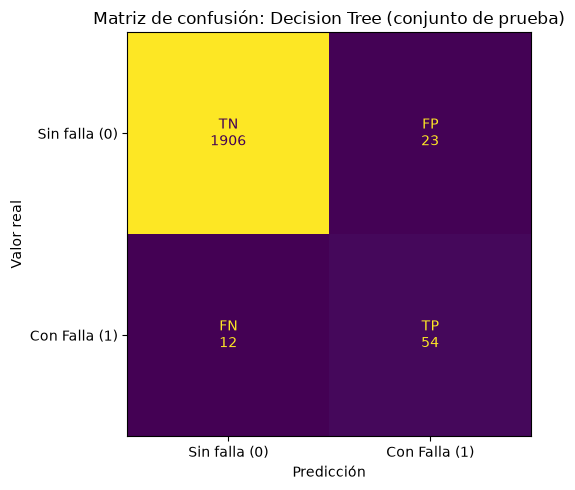

In [35]:
# Matriz de confusión del baseline en el conjunto de prueba
fig, ax = plt.subplots(figsize=(6, 5))
display_cm = ConfusionMatrixDisplay.from_estimator(tree_pipeline, X_test, y_test,
                                                   display_labels=["Sin falla (0)", "Con Falla (1)"],
                                                   cmap="viridis", colorbar=False, ax=ax,
)

cell_names = [["TN", "FP"],
              ["FN", "TP"]]
for row in range(2):
    for col in range(2):
        text = display_cm.text_[row, col]
        text.set_text(f"{cell_names[row][col]}\n{text.get_text()}")

ax.set_title("Matriz de confusión: Decision Tree (conjunto de prueba)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()


### 5.3 Reporte de clasificación del *baseline*

`classification_report` muestra *precision*, *recall* y *F1* para cada clase, junto con *support*.

In [36]:
# Reporte detallado por clase del Decision Tree
y_pred_tree = tree_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_tree,
                            target_names=["Sin falla (0)", "Con Falla (1)"],
                            digits=4,
))

               precision    recall  f1-score   support

Sin falla (0)     0.9937    0.9881    0.9909      1929
Con Falla (1)     0.7013    0.8182    0.7552        66

     accuracy                         0.9825      1995
    macro avg     0.8475    0.9031    0.8731      1995
 weighted avg     0.9841    0.9825    0.9831      1995



### 5.4 Revisión de overfitting

Un Decision Tree sin límite de profundidad puede memorizar los datos de entrenamiento. Para revisarlo, se comparan las métricas en entrenamiento y en prueba: una diferencia grande indica overfitting.

In [37]:
# Métricas del Decision Tree en entrenamiento contra prueba
tree_train_metrics = evaluate(tree_pipeline, X_train, y_train)

overfitting_check = pd.DataFrame({"train": tree_train_metrics,
                                  "test": tree_metrics},
).round(4)
overfitting_check["diferencia"] = (overfitting_check["train"] - overfitting_check["test"]).round(4)
overfitting_check

,train,test,diferencia
accuracy,1.0,0.9825,0.0175
precision,1.0,0.7013,0.2987
recall,1.0,0.8182,0.1818
f1,1.0,0.7552,0.2448


### 5.5 Importancia de las *features*

El Decision Tree indica cuánto contribuye cada *feature* a sus decisiones. Sirve para verificar que el modelo usa las variables que el EDA identificó como relevantes.

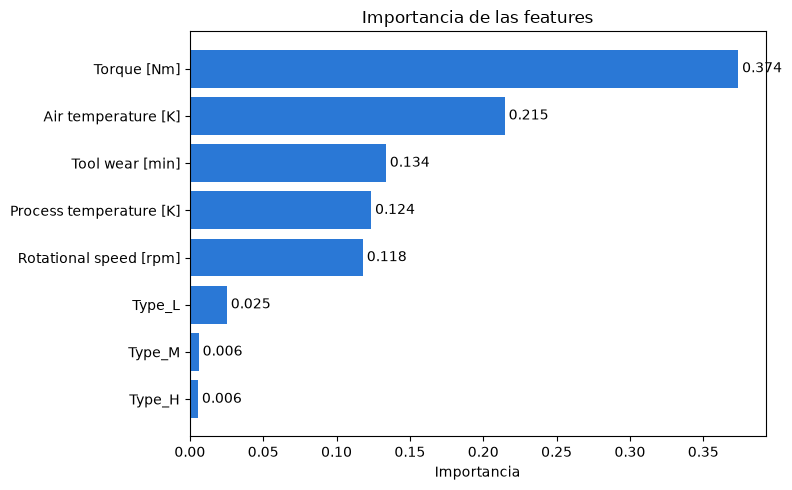

In [38]:
# Importancia de cada feature en el Decision Tree, de mayor a menor
importances = (pd.Series(tree.feature_importances_, index=feature_names)
               .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances.values, color=BLUE)
for i, value in enumerate(importances.values):
    ax.text(value, i, f" {value:.3f}", va="center")
ax.set_title("Importancia de las features")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

### 5.6 Interpretación de los resultados

**Desempeño del *baseline* Decision Tree en el conjunto de prueba:**
- **Recall = 0.8182:** el modelo detecta 54 de las 66 fallas reales; 12 fallas pasan sin ser detectadas. En mantenimiento predictivo, este es el error más costoso, porque corresponde a paros no planeados.
- **Precision = 0.7013:** de las 77 alertas de falla que emite el modelo, 54 son fallas reales y 23 son falsas alarmas. En operación, aproximadamente 7 de cada 10 inspecciones generadas por el modelo encontrarían una falla real.
- **F1 = 0.7552:** resume el equilibrio entre ambas métricas y es la referencia contra la cual se compararán futuras versiones del modelo.

**Comparación con el modelo Dummy:**
- **La *accuracy* confirma ser engañosa:** el modelo dummy que siempre predice "sin falla" obtiene 0.9669 de *accuracy* sin detectar una sola falla (*recall* = 0), y el Decision Tree solo lo supera por 1.56 puntos (0.9825), a pesar de detectar el 81.82% de las fallas. La diferencia real entre modelos solo se ve en *recall*, *precision* y *F1*.

**Overfitting:** el Decision Tree obtiene métricas perfectas en entrenamiento (1.0) y F1 de 0.7552 en prueba, una diferencia de 0.2448. Con profundidad 23 y 130 hojas, el Decision Tree está memorizando datos de entrenamiento. Es el comportamiento esperado sin ajuste de hiperparámetros, y es aceptable en un *baseline*. Esto nos da pautas de los ajustes a intentar: limitar la profundidad (`max_depth`) o el tamaño mínimo de las hojas (`min_samples_leaf`), eligiendo los valores con *cross-validation*.

**Importancia de las features:** `Torque [Nm]` es la *feature* más importante (0.374), seguida de `Air temperature [K]` (0.215), `Tool wear [min]` (0.134), `Process temperature [K]` (0.124) y `Rotational speed [rpm]` (0.118); `Type` aporta poco. Este orden es coherente con los mecanismos de falla descritos en la documentación del dataset: el torque interviene en las fallas de potencia y de sobreesfuerzo, las temperaturas en la falla por disipación de calor, y el desgaste de la herramienta en las fallas por desgaste y sobreesfuerzo. El modelo aprendió patrones con sentido físico, no artefactos de los datos.

**Observación final:** las métricas provienen de un solo train/test split con 66 fallas en el conjunto de prueba, por lo que tienen variabilidad. Unas pocas fallas más o menos detectadas mueven el *recall* varios puntos. Una evaluación más robusta usaría *Stratified K-Fold Cross-Validation*.

## Paso 6: Registro del experimento en MLflow Tracking

MLflow Tracking guarda cada entrenamiento como un *run* dentro de un experimento, con todo lo necesario para reproducirlo y compararlo después. En este *run* se registra:
- **Parámetros:** configuración del experimento (random seed, tamaño del conjunto de prueba, estratificación) e hiperparámetros del Decision Tree.
- **Métricas:** *accuracy*, *precision*, *recall* y *F1* en prueba y en entrenamiento, además de la profundidad y el número de hojas del árbol.
- **Tags:** dataset, etapa del modelo y autor, para identificar el *run*.
- **Artefactos:** el dataset limpio usado para entrenar (trazabilidad de los datos) y el modelo completo (pipeline de preprocesamiento + Decision Tree), con su *signature* (esquema de entrada y salida) y un ejemplo de entrada.

El registro se hace a través de un servidor local de MLflow (`http://127.0.0.1:5000`): el servidor guarda los metadatos en `mlflow.db` (SQLite) y los artefactos en la carpeta `mlartifacts/`, ambos en la raíz del repositorio y excluidos de Git en `.gitignore`.

### 6.1 Configuración del experimento

**Requisito:** antes de ejecutar esta sección, el servidor de MLflow debe estar activo. Desde una terminal en la raíz del repositorio, con el ambiente `mlops` activo:

```bash
mlflow ui --port 5000
```

Si el servidor no está activo, la conexión a `http://127.0.0.1:5000` falla.

In [39]:
# Ubicación del tracking y experimento (se crea si no existe)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experimento :", experiment.name, "| ID:", experiment.experiment_id)

2026/10/03 22:11:37 INFO mlflow.tracking.fluent: Experiment with name 'AI4I_Predictive_Maintenance' does not exist. Creating a new experiment.


Tracking URI: http://127.0.0.1:5000
Experimento : AI4I_Predictive_Maintenance | ID: 1


### 6.2 Registro del *run*

**Nota sobre el guardado del modelo:** desde la versión 3 de MLflow, los modelos de scikit-learn se guardan con el formato `skops`, más seguro que `pickle` porque no permite ejecutar código arbitrario al cargar un archivo. Por esa misma seguridad, `skops` rechaza por defecto el tipo interno `sklearn.tree._tree.Tree`, que almacena la estructura del árbol. Como el modelo fue entrenado en este mismo notebook y su origen es confiable, se declara ese tipo en `skops_trusted_types`.

In [40]:
# Parámetros del experimento e hiperparámetros del Decision Tree
params = {"model_type": "DecisionTreeClassifier",
          "seed": SEED,
          "test_size": TEST_SIZE,
          "stratify": TARGET,
          "n_train": len(X_train),
          "n_test": len(X_test),
          "n_features": X.shape[1],
}
params.update({f"model__{name}": value for name, value in tree.get_params().items()})

# Métricas en prueba y entrenamiento, más la complejidad del árbol entrenado
metrics = {f"test_{name}": value for name, value in tree_metrics.items()}
metrics.update({f"train_{name}": value for name, value in tree_train_metrics.items()})
metrics.update({"tree_depth": tree.get_depth(),
                "tree_n_leaves": tree.get_n_leaves(),
})

# Signature: esquema de entrada (features) y salida (predicción) del modelo
signature = infer_signature(X_train, tree_pipeline.predict(X_train))

with mlflow.start_run(run_name="decision_tree_baseline") as run:
    mlflow.log_params(params)
    mlflow.log_metrics(metrics)
    mlflow.set_tags({"dataset": "AI4I 2020 Predictive Maintenance (limpio)",
                     "stage": "baseline",
                     "author": "Daniel Sánchez Hernández",
    })

    # Dataset limpio usado para entrenar (trazabilidad de los datos)
    mlflow.log_artifact(str(PROCESSED_PATH), artifact_path="data")

    # Modelo completo: pipeline de preprocesamiento + Decision Tree
    model_info = mlflow.sklearn.log_model(sk_model=tree_pipeline,
                                          name="decision_tree_baseline",
                                          signature=signature,
                                          input_example=X_train.head(5),
                                          skops_trusted_types=["sklearn.tree._tree.Tree"],
    )

print("Run ID   :", run.info.run_id)
print("Model URI:", model_info.model_uri)
print(f"Registrados: {len(params)} parámetros, {len(metrics)} métricas")

/home/daniel/miniconda3/envs/mlops/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run decision_tree_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/f0528aadbd314a71a7388346b0501da4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run ID   : f0528aadbd314a71a7388346b0501da4
Model URI: models:/m-56ae11873b3d488aa71c7aede7614053
Registrados: 20 parámetros, 10 métricas


### 6.3 Verificación del registro

Se comprueba que el *run* quedó guardado consultando MLflow directamente, y que el modelo registrado es reproducible: al cargarlo desde MLflow debe producir exactamente las mismas predicciones que el modelo entrenado en el notebook.

In [41]:
# Consulta del run en MLflow: métricas principales tal como quedaron registradas
logged_run = mlflow.get_run(run.info.run_id)
logged_metrics = pd.Series(logged_run.data.metrics).loc[["test_accuracy", "test_precision", "test_recall", "test_f1"]]
print("Métricas registradas en MLflow:")
print(logged_metrics.round(4).to_string())

# Carga del modelo desde MLflow y comparación de predicciones con el modelo en memoria
loaded_model = mlflow.sklearn.load_model(model_info.model_uri)
same_predictions = (loaded_model.predict(X_test) == tree_pipeline.predict(X_test)).all()
print("\nEl modelo cargado desde MLflow produce las mismas predicciones:", same_predictions)
assert same_predictions, "El modelo cargado no reproduce las predicciones"

Métricas registradas en MLflow:
test_accuracy     0.9825
test_precision    0.7013
test_recall       0.8182
test_f1           0.7552



El modelo cargado desde MLflow produce las mismas predicciones: True


### 6.4 Consulta en la interfaz de MLflow

La interfaz de MLflow la sirve el mismo servidor iniciado en la sección 6.1. Al abrirlo, se muestra el experimento `AI4I_Predictive_Maintenance` y el *run* `decision_tree_baseline`, donde se ven los parámetros, las métricas, los tags y los artefactos registrados.

Cada ejecución completa del notebook registra un *run* nuevo en el experimento; esto es el comportamiento esperado de MLflow y permite comparar ejecuciones entre sí.

### 6.5 Incluye una captura de la interfaz de MLFlow que evidencie el experimento registrado

![alt text](MLflow-Experiment.png)

![alt text](MLflow-Run.png)